In [1]:
!pip install neuraloperator

In [2]:
import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from neuralop.models import FNO
from torch.utils.data import TensorDataset, DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
print(torch.cuda.is_available())

cuda
True


In [4]:
from google.colab import files

uploaded = files.upload()

Saving burgers_train_16.pt to burgers_train_16 (2).pt
Saving burgers_test_16.pt to burgers_test_16 (2).pt


In [5]:
train = torch.load("burgers_train_16.pt")
test  = torch.load("burgers_test_16.pt")

#loading data
x_train = train["x"]
y_train = train["y"]

x_test = test["x"]
y_test = test["y"]

print(x_train.shape)
print(y_train.shape)

torch.Size([800, 16])
torch.Size([800, 17, 16])


In [6]:
y_train = y_train[:, -1, :]
y_test  = y_test[:, -1, :]

#taking the last time instant
print(y_train.shape)

torch.Size([800, 16])


In [7]:
x_train = x_train.unsqueeze(1)
y_train = y_train.unsqueeze(1)

x_test = x_test.unsqueeze(1)
y_test = y_test.unsqueeze(1)

#adjusting to appropriate shape
print(x_train.shape)
print(y_train.shape)

torch.Size([800, 1, 16])
torch.Size([800, 1, 16])


In [8]:
x_train = x_train.float()
y_train = y_train.float()

x_test = x_test.float()
y_test = y_test.float()

In [9]:
#using batch size for better and faster results
train_loader = DataLoader(
    TensorDataset(x_train, y_train),
    batch_size=32,
    shuffle=True,
)

test_loader = DataLoader(
    TensorDataset(x_test, y_test),
    batch_size=32,
    shuffle=False,
)

In [10]:
#model since i am using new version it has few changes in the syntax
model = FNO(
    n_modes=(16,),
    in_channels=1,
    out_channels=1,
    hidden_channels=64,
    n_layers=4,
    lifting_channel_ratio=2,
    projection_channel_ratio=2, # using newer version
).to(device)

print(model)

FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([64, 64, 9]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
          (1): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(2, 128, kernel_size=(1,), stride=(1,))
      (1): Conv1d(128, 64, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (1): Conv1d(128, 1, kernel_size=(

In [ ]:
import torch.nn as nn
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [12]:
epochs = 100

train_losses = []

for epoch in range(epochs):

    model.train()
    epoch_loss = 0.0

    #loading a batch and using it optimize
    for x, y in train_loader:

        x = x.to(device).float()
        y = y.to(device).float()

        optimizer.zero_grad()

        y_pred = model(x)

        loss = criterion(y_pred, y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Loss = {epoch_loss:.6f}")

Epoch  10 | Loss = 0.000006
Epoch  20 | Loss = 0.000001
Epoch  30 | Loss = 0.000001
Epoch  40 | Loss = 0.000000
Epoch  50 | Loss = 0.000000
Epoch  60 | Loss = 0.000000
Epoch  70 | Loss = 0.000000
Epoch  80 | Loss = 0.000001
Epoch  90 | Loss = 0.000001
Epoch 100 | Loss = 0.000000


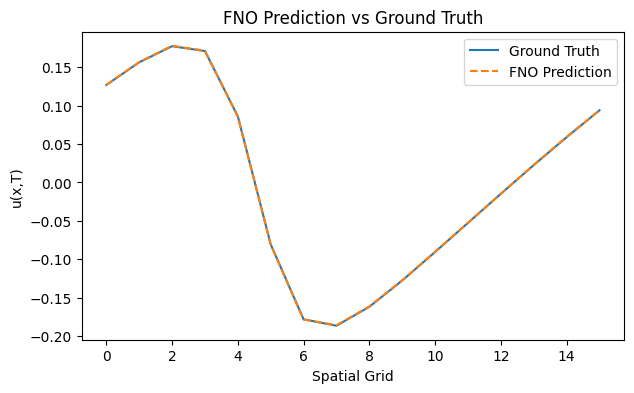

In [13]:
model.eval()

with torch.no_grad():

    x = x_test[0:1].float().to(device)

    pred = model(x).cpu().numpy()[0,0]

truth = y_test[0,0].numpy()

plt.figure(figsize=(7,4))
plt.plot(truth,label="Ground Truth")
plt.plot(pred,"--",label="FNO Prediction")
plt.legend()
plt.xlabel("Spatial Grid")
plt.ylabel("u(x,T)")
plt.title("FNO Prediction vs Ground Truth")
plt.show()

In [14]:
model.eval()

l2_error = 0.0

with torch.no_grad():

    for x, y in test_loader:

        x = x.float().to(device)
        y = y.float().to(device)

        y_pred = model(x)

        l2_error += torch.norm(y_pred - y).item() / torch.norm(y).item()

l2_error /= len(test_loader)

print("Test L2 Relative Error:", l2_error)

Test L2 Relative Error: 0.0029058256856086097


/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

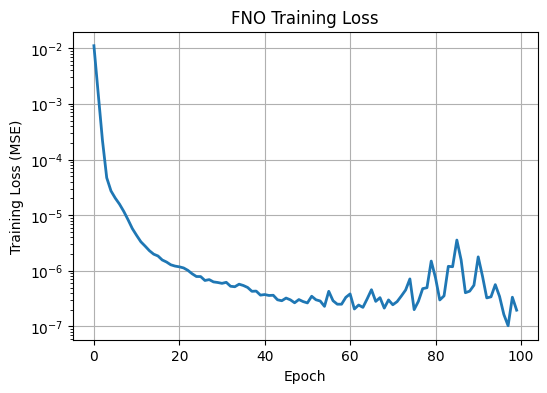

In [16]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.yscale("log")
plt.title("FNO Training Loss")
plt.grid(True)
plt.show()